# Ex. Single ERT File Inversion (No Time-Lapse)

This notebook shows a simple one-file ERT workflow using `ert_data_agent` functions directly:
1. Set a folder path or file path (default uses DAS example data).
2. (Optional) enable external `electrodes.dat` usage via `use_electrode_file`.
3. Process data (`load_ert_resipy`, `qc_and_visualize`, `export_for_inversion`).
4. Run one `ERTInversion`.
5. Save model outputs.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path.cwd()

if (current_dir / "data" / "ERT").exists():
    examples_dir = current_dir
elif (current_dir / "examples" / "data" / "ERT").exists():
    examples_dir = current_dir / "examples"
else:
    examples_dir = current_dir

repo_root = examples_dir.parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from PyHydroGeophysX.data_processing.ert_data_agent import (
    LocalRef,
    export_for_inversion,
    load_ert_resipy,
    qc_and_visualize,
)
from PyHydroGeophysX.inversion.ert_inversion import ERTInversion

C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\__init__.py:15: FutureWarning: Importing `SimPEG` is deprecated. please import from `simpeg`.
  import SimPEG as _simpeg


API path =  C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy
ResIPy version =  3.5.4
cR2.exe found and up to date.
R3t.exe found and up to date.
cR3t.exe found and up to date.
[PyHydroGeophysX] RESIPY loaded successfully
[PyHydroGeophysX] PyGIMLi loaded successfully
[PyHydroGeophysX] SimPEG loaded successfully (version 0.24.0)


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy\meshTools.py:56: UserWarning: pyvista not installed, 3D meshing viewing options will be limited
  warnings.warn('pyvista not installed, 3D meshing viewing options will be limited')


## Default dataset: examples/data/ERT/DAS


In [2]:
# Default dataset: examples/data/ERT/DAS
input_path = examples_dir / "data" / "ERT" / "DAS"
instrument = "DAS-1"

# Optional external electrode coordinate file
use_electrode_file = True
electrode_file = input_path / "electrodes.dat"  # used only if use_electrode_file=True

# Error mode: False=recompute reciprocal error, True=use source error
use_source_error = False

output_dir = examples_dir / "results" / "ert_single_inversion_notebook"
output_dir.mkdir(parents=True, exist_ok=True)

# Pick first data file from the folder
candidates = sorted(list(input_path.glob("*.Data")) + list(input_path.glob("*.data")) + list(input_path.glob("*.dat")) + list(input_path.glob("*.ohm")))
if not candidates:
    raise FileNotFoundError(f"No ERT data file found in {input_path}")
data_file = candidates[0]

print(f"Input folder: {input_path}")
print(f"Using file: {data_file}")
print(f"use_electrode_file: {use_electrode_file}")
print(f"use_source_error: {use_source_error}")
print(f"Output dir: {output_dir}")


Input folder: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\DAS
Using file: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\DAS\20171105_1418.Data
use_electrode_file: True
use_source_error: False
Output dir: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook


Using electrode file: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\DAS\electrodes.dat
Working directory is: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\DAS
filterData: 0 / 945 quadrupoles removed.
930/945 reciprocal measurements found.
0 measurements error > 20 %
   Loaded 945 raw resistance measurements from DAS-1
   Updated electrode positions from electrodes.dat
   After basic QC filters: 945 measurements
   Applied reciprocal error filter (< 5%): removed 15 measurements
   Total filtered with DAS quality thresholds: 15 measurements
   After all QC filters: 930 measurements


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy\parsers.py:2012: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfElec_raw = pd.read_csv(io.StringIO(cleanData), delim_whitespace=True, skiprows=elec_lineNum_s[0],
C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy\Project.py:2941: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  array = self.surveys[0].df[['a','b','m','n']].replace(lookupDict).values.copy().astype(int) # strings don't have max/min


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy\parsers.py:2012: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfElec_raw = pd.read_csv(io.StringIO(cleanData), delim_whitespace=True, skiprows=elec_lineNum_s[0],
C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy\Project.py:2941: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  array = self.surveys[0].df[['a','b','m','n']].replace(lookupDict).values.copy().astype(int) # strings don't have max/min
28/03/26 - 20:28:49 - pyGIMLi - INFO - Create default mesh for geometric factor calculation.


   DEBUG: Writing 56 electrodes to file
   DEBUG: First electrode: x=21.375, y=2965.981, z=0.000
   DEBUG: Last electrode: x=103.875, y=2939.099, z=0.000
   DEBUG: Coordinate ranges: x=[21.375, 103.875], y=[2938.389, 2965.981], z=[0.000, 0.000]
   DEBUG: Inferred elevation axis: y
   DEBUG: app_res source metadata: resistance
   DEBUG: Export strategy: default reciprocal-pair path
   DEBUG: Error mode: abs((relative * resist + absolute) / recipMean) with relative=0.0100, absolute=0.0010
Working directory is: C:\Users\hchen117\AppData\Local\Temp\phgx_default_export_hicjdgvw
filterData: 0 / 945 quadrupoles removed.
930/945 reciprocal measurements found.
0 measurements error > 20 %
14 measurements outside [0.1,10000.0] removed!
filterData: 0 / 931 quadrupoles removed.
0 measurements with greater than 10.0% reciprocal error removed!
Error model is R_err = 5.51e-04*R_avg + 0.029 (R^2 = 0.799)
   DEBUG: Default export retained 465 reciprocal-paired measurements
   DEBUG: Preserved default ex

28/03/26 - 20:28:51 - pyGIMLi - INFO - Save RVector binary


28/03/26 - 20:28:51 - pyGIMLi - INFO - Cache stored: C:\Users\hchen117\AppData\Roaming\pygimli\Cache\5429967807884118336


   Computed K range: [9.3, 155.4]
   Final dataset: 465 measurements with computed K
   DEBUG: Preserved default export errors on final rows: valid=465/465, err_range=[0.010, 0.010]
   Saved data with computed K to C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\bert_data.dat
Instrument used: DAS-1
BERT export: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\bert_data.dat
QC artifacts:
  electrodes_png: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\electrodes.png
  rhoa_hist_png: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\rhoa_hist.png
  observations_parquet: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_singl

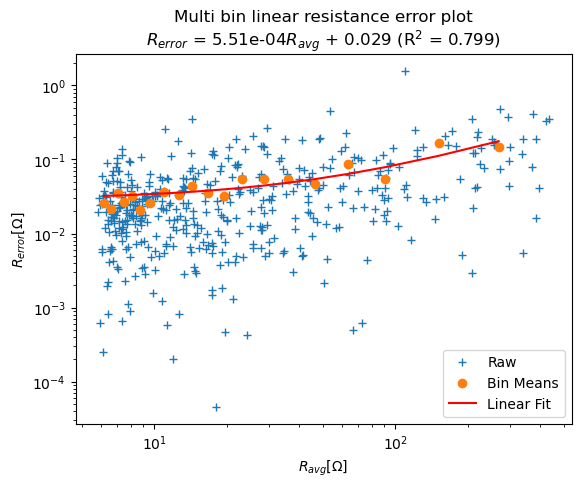

In [3]:
electrode_file_arg = None
if use_electrode_file:
    if not Path(electrode_file).exists():
        raise FileNotFoundError(f"Electrode file not found: {electrode_file}")
    electrode_file_arg = str(electrode_file)
    print(f"Using electrode file: {electrode_file_arg}")

ert = load_ert_resipy(
    project_dir=str(input_path),
    data_file=str(data_file),
    instrument=instrument,
    electrode_file=electrode_file_arg,
    crs="local",
    local_ref=LocalRef(origin_x=0.0, origin_y=0.0, azimuth_deg=90.0),
)

artifacts = qc_and_visualize(ert, outdir=str(output_dir))
bert_path = export_for_inversion(
    ert,
    outdir=str(output_dir),
    fmt="pgimli",
    use_source_error=use_source_error,
)

print(f"Instrument used: {instrument}")
print(f"BERT export: {bert_path}")
print("QC artifacts:")
for k, v in artifacts.items():
    print(f"  {k}: {v}")


In [4]:
inversion = ERTInversion(
    data_file=bert_path,
    lambda_val=10.0,
    method="cgls",
    max_iterations=10,
    lambda_rate=1.0,
    use_gpu=False,
)
result = inversion.run()

28/03/26 - 20:28:51 - pyGIMLi - INFO - Found 2 regions.


28/03/26 - 20:28:51 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


28/03/26 - 20:28:52 - pyGIMLi - INFO - Found 2 regions.


28/03/26 - 20:28:52 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


28/03/26 - 20:28:52 - pyGIMLi - INFO - Creating forward mesh from region infos.


...

chi2: 54.33660849686754
dPhi: 0.7413035502377291


-------------------Iteration: 3 ---------------------------


chi2: 16.11535448871758
dPhi: 0.7034162614391619


-------------------Iteration: 4 ---------------------------
chi2: 0.5111644869888997
dPhi: 0.9682809033244184


End of inversion


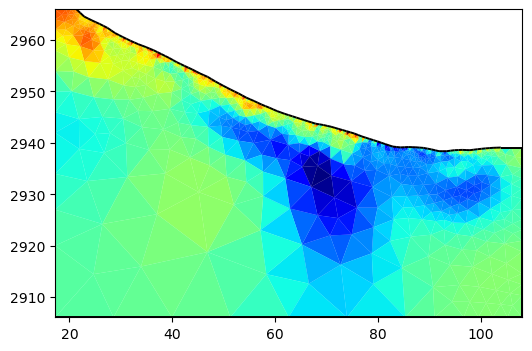

C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1000x400 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


<Figure size 640x480 with 0 Axes>

Saved model figure: C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\single_ert_model_notebook.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))


pg.show(
    result.mesh,
    result.final_model,
    ax=ax,
    cMap="jet",
    logScale=True,
    coverage=result.coverage>-1,
    label="Resistivity [Ohm-m]",
)
ax.set_title("Single ERT Inversion Result")
fig.tight_layout()

fig_path = output_dir / "single_ert_model_notebook.png"
fig.savefig(fig_path, dpi=200)
plt.show()

np.save(output_dir / "final_model.npy", result.final_model)
np.save(output_dir / "predicted_data.npy", result.predicted_data)
np.save(output_dir / "coverage.npy", result.coverage)
print(f"Saved model figure: {fig_path}")

(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x1b1e2140640>)

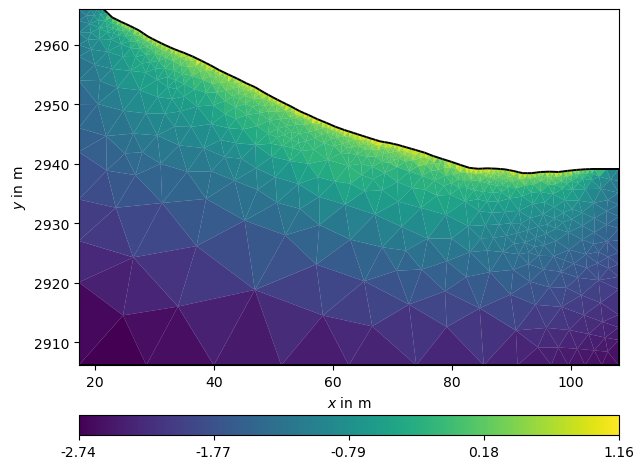

In [6]:
pg.show(result.mesh,result.coverage)

To run the script version from terminal:

```bash
python examples/Ex_ERT_single_inversion.py --input examples/data/ERT/DAS --instrument DAS-1
# Optional electrode file mode:
python examples/Ex_ERT_single_inversion.py --input examples/data/ERT/DAS --instrument DAS-1 --use-electrode-file --electrode-file examples/data/ERT/DAS/electrodes.dat
```
